In [ ]:
# This code is part of QCMet.
# 
# (C) Copyright 2024 National Physical Laboratory and National Quantum Computing Centre 
# 
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
# 
#      http://www.apache.org/licenses/LICENSE-2.0
# 
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License


## Quantum Fourier transform metric

In [1]:
import qiskit
import numpy as np
import matplotlib.pyplot as plt

import sys
import pathlib
import os
sys.path.insert(0, str(pathlib.Path(os.path.abspath('')).parent.parent.parent.resolve()))

from _helpers.circuit_submitter import *

In [29]:
n_qubits = 6
device_name = "noisy_sim"
shots = 1000
submitter = CircuitSubmitter("qft", device_name)
# Uncomment the following lines if you are using a noisy simulator and would like to change the noise model
# noise_model = None
# submitter.backend.device.noisy_sim.set_options(noise_model=noise_model)

NoiseModel:
  Basis gates: ['cx', 'id', 'rz', 'sx']
  Instructions with noise: ['cx']
  All-qubits errors: ['cx']


In [22]:
def qft(n_qubits, inverse=False):
    qc = QuantumCircuit(n_qubits, n_qubits)

    for i in (range(n_qubits)):
        qc.h(i)
        for j in (range(i + 1, n_qubits)):
            lam = np.pi * (2.0 ** (i - j))
            qc.cp(lam, j, i)

    for i in range(n_qubits // 2):
        qc.swap(i, n_qubits - i - 1)

    if inverse:
        qc = qc.inverse()
        
    return qc

### Create circuit

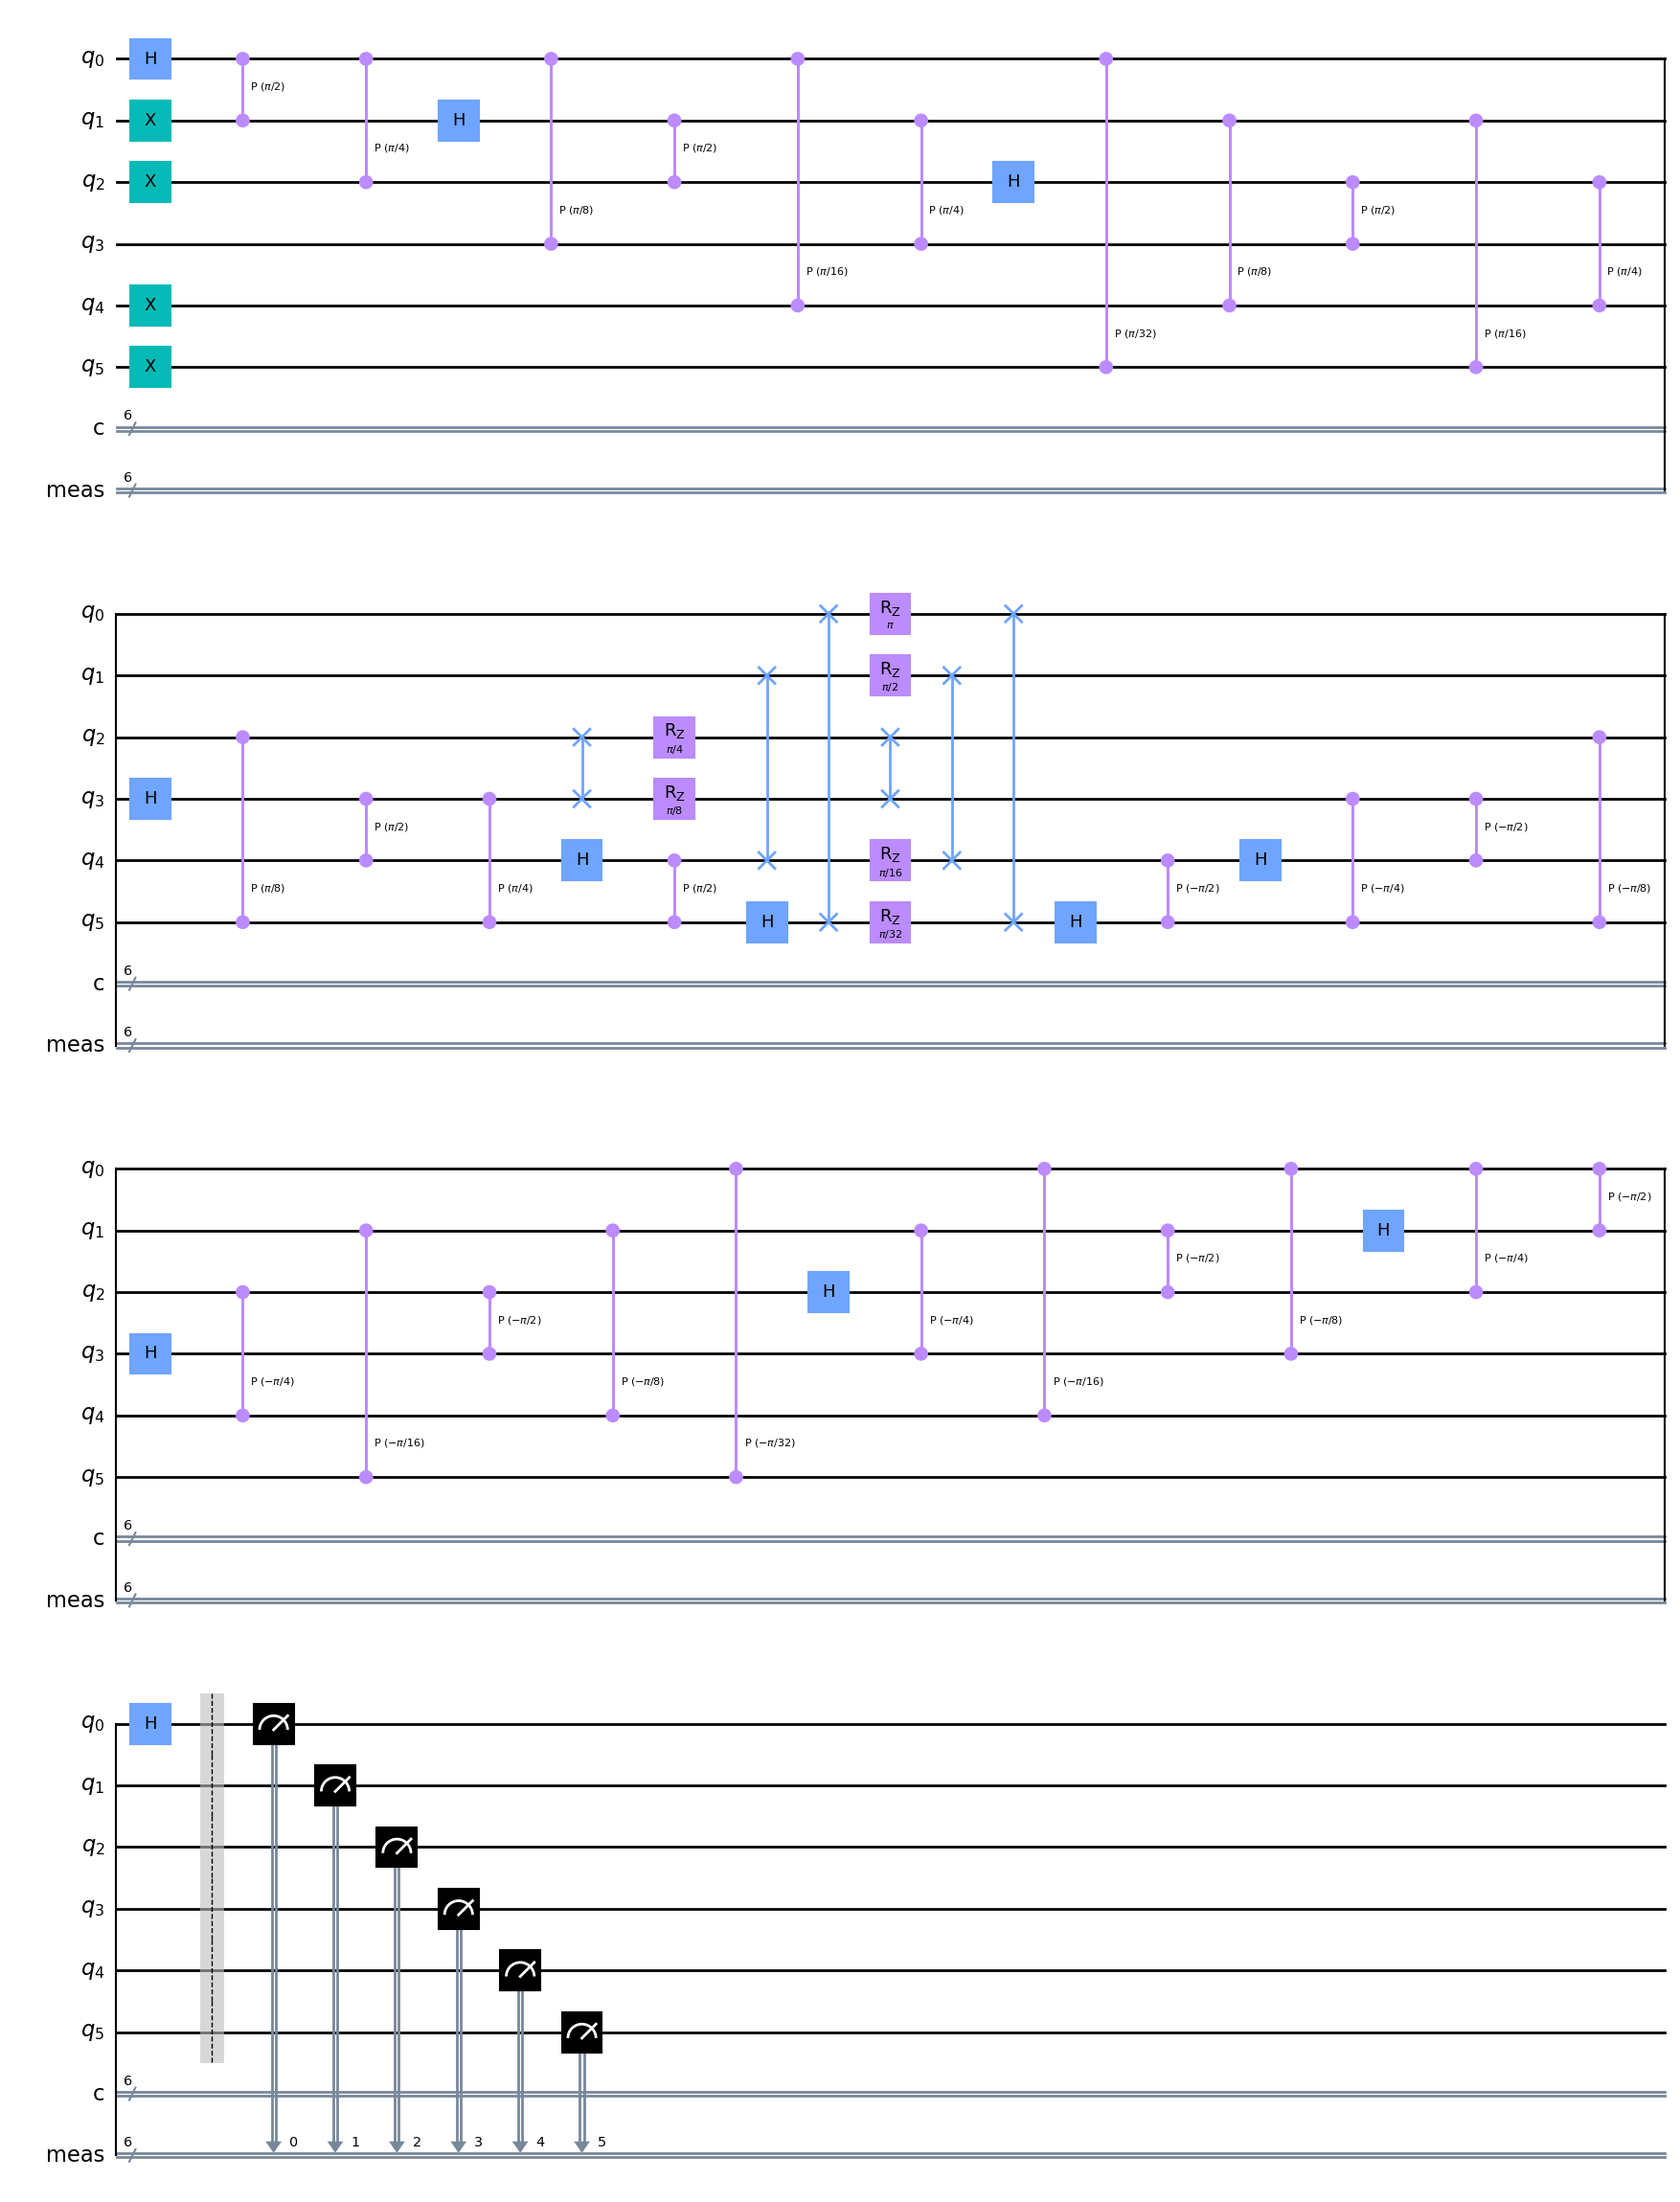

In [27]:
qc = QuantumCircuit(n_qubits, n_qubits)

# Random initial state. Seed for reproducibility
np.random.seed(0)
random_initialisation = np.random.randint(0, 2, n_qubits)

for i, flag in enumerate(random_initialisation):
    if flag == 1:
        qc.x(i)
qc = qc & qft(n_qubits)

for i in range(n_qubits):
    qc.rz(np.pi / 2 ** i, i)

qc = qc & qft(n_qubits, inverse=True)
qc.measure_all()

qc.draw(style="clifford", output="mpl")

### Run circuit

In [39]:
submitter.submit_circuits(shots=shots, verbatim=False, skip_asking=True, qasm_strs=[qc.qasm()])
counts = submitter.retrieve_counts()
print(counts)

Ready to run 1 circuits on noisy_sim with 1000 shots.
Cost: 1 * ($0 + 1000 * $0) = $0.00.
Circuits have been submitted
2024-07-02 13:34:00 All circuits are finished
[{'000000': 0, '100000': 0, '010000': 0, '110000': 0, '001000': 0, '101000': 0, '011000': 0, '111000': 0, '000100': 0, '100100': 0, '010100': 0, '110100': 0, '001100': 0, '101100': 0, '011100': 1000, '111100': 0, '000010': 0, '100010': 0, '010010': 0, '110010': 0, '001010': 0, '101010': 0, '011010': 0, '111010': 0, '000110': 0, '100110': 0, '010110': 0, '110110': 0, '001110': 0, '101110': 0, '011110': 0, '111110': 0, '000001': 0, '100001': 0, '010001': 0, '110001': 0, '001001': 0, '101001': 0, '011001': 0, '111001': 0, '000101': 0, '100101': 0, '010101': 0, '110101': 0, '001101': 0, '101101': 0, '011101': 0, '111101': 0, '000011': 0, '100011': 0, '010011': 0, '110011': 0, '001011': 0, '101011': 0, '011011': 0, '111011': 0, '000111': 0, '100111': 0, '010111': 0, '110111': 0, '001111': 0, '101111': 0, '011111': 0, '111111': 0

In [40]:
# Convert base 2 into base 10
counts = {int(key, 2): value for key, value in counts[0].items()}
# Sort according to ascending order of bit strings
counts = np.array([counts[i] if i in counts.keys() else 0 for i in range(2 ** n_qubits)])
# Convert to probabilities
hardware_probs = counts / shots
print(hardware_probs)

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


### Visualisation of results

In [41]:
random_initialisation

array([0, 1, 1, 0, 1, 1])

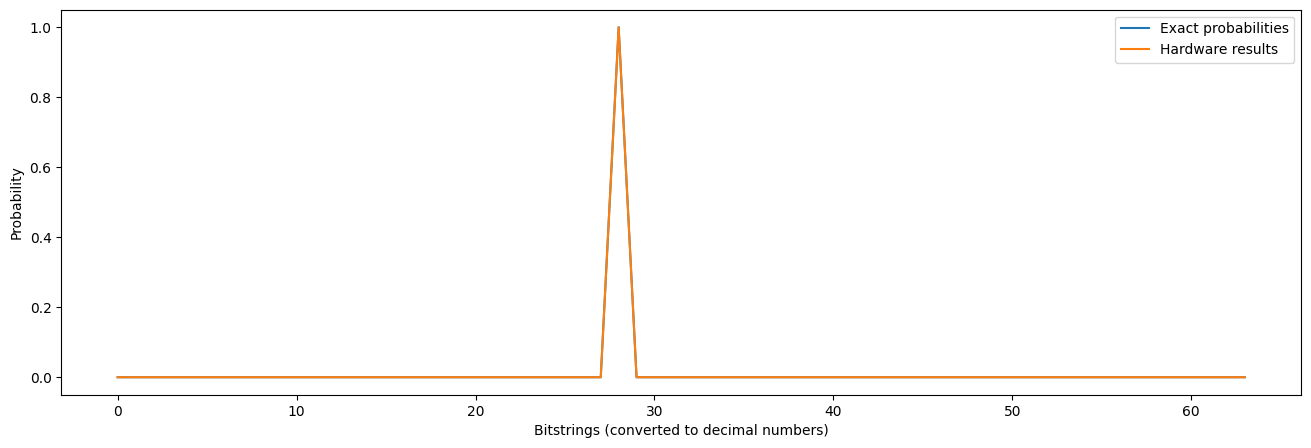

In [44]:
exact_probs = np.zeros(len(hardware_probs))
exact_probs[(sum(v * (2 ** i) for i, v in enumerate(reversed(random_initialisation))) + 1) % (2 ** n_qubits)] = 1

plt.figure(figsize=(16, 5))
plt.plot(exact_probs, label="Exact probabilities")
plt.plot(hardware_probs, label="Hardware results")
plt.xlabel("Bitstrings (converted to decimal numbers)")
plt.ylabel("Probability")
plt.legend()
plt.savefig(submitter.benchmark_path + "/plot.png", format="png")
plt.show()

### Compute normalised fidelity

In [46]:
def fidelity(P1, P2):
    assert len(P1) == len(P2)
    
    f = 0
    for i in range(len(P1)):
        f += np.sqrt(P1[i] * P2[i])
    
    f = f ** 2
    
    return f

uniform_dist = np.array([1 for _ in exact_probs]) / len(exact_probs)

f_ideal_and_output = fidelity(exact_probs, hardware_probs)
f_ideal_and_uniform = fidelity(exact_probs, uniform_dist)


f_ideal_and_hardware = fidelity(exact_probs, hardware_probs)

normalised_fidelity = max((f_ideal_and_hardware - f_ideal_and_uniform) / (1 - f_ideal_and_uniform), 0)
print(f"The normalised fidelity between the exact result and the hardware result is {normalised_fidelity}")

# Save into data directory
result_str = (f"Quantum Fourier Transform benchmark with n_qubits = {n_qubits}, random initialization {random_initialisation}\n"
                f"Exact (ideal) probabilities: {exact_probs}\n" 
                f"Obtained (hardware) probabilities: {hardware_probs}\n" 
                f"The normalised fidelity between the exact result and the hardware result is {normalised_fidelity}")
with open(submitter.benchmark_path + "/results.txt", "w+") as f:
    f.write(result_str)
print(result_str)
print(f"The above results are saved into {submitter.benchmark_path + '/results.txt'}")

The normalised fidelity between the exact result and the hardware result is 1.0
Quantum Fourier Transform benchmark with n_qubits = 6, random initialization [0 1 1 0 1 1]
Exact (ideal) probabilities: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Obtained (hardware) probabilities: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
The normalised fidelity between the exact result and the hardware result is 1.0
The above results are saved into /hpc-work/wz2/shared-nqcc/_helpers/../hardware_runs/noisy_sim/2024-07-02/qft/results.txt


In [47]:
(f_ideal_and_hardware - f_ideal_and_uniform) / (1 - f_ideal_and_uniform)

1.0